## Prepare MCMC results to merge with DEMOGORGN
Mickey MacKie
4/14/26

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

/Users/sinanhe/Documents/demogorgn/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
beds = np.load('MCMC_results/MCMC_1.npy')
df = pd.read_csv('MertzGlacierDataGridded_2.csv')
df

,x,y,surf,bed,velx,vely,smb,dhdt,highvel_mask,bedmap_mask,bedmap_surf,bedmachine_source,bedmachine_thickness,bedmachine_bed,bedmap_bed,radar_thickness
0,1382750,-2077750,NaN,NaN,NaN,NaN,-0.000002,NaN,0,NaN,NaN,1.0,563.356079,-563.472866,-563.0,NaN
1,1383250,-2077750,NaN,NaN,NaN,NaN,-0.000002,NaN,0,NaN,NaN,1.0,562.376221,-562.504192,-562.0,NaN
2,1383750,-2077750,NaN,NaN,NaN,NaN,-0.000002,NaN,0,NaN,NaN,1.0,561.779175,-561.918331,-562.0,NaN
3,1384250,-2077750,NaN,NaN,NaN,NaN,-0.000002,NaN,0,NaN,NaN,1.0,561.237274,-561.387616,-561.0,NaN
4,1384750,-2077750,NaN,NaN,NaN,NaN,-0.000002,NaN,0,NaN,NaN,1.0,560.799286,-560.960813,-561.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146050,1540750,-1850750,1753.0,NaN,-4.484581,-20.867483,0.316744,0.066543,0,1.0,1753.0,5.0,1799.933960,-67.698095,-16.0,NaN
146051,1541250,-1850750,1753.0,NaN,-6.778050,-19.492045,0.317021,0.067734,0,1.0,1753.0,5.0,1799.406677,-66.938766,-17.0,NaN
146052,1541750,-1850750,1754.0,NaN,-8.480189,-18.389309,0.317298,0.069036,0,1.0,1754.0,5.0,1798.809631,-65.900125,-17.0,NaN
146053,1542250,-1850750,1754.0,NaN,-7.330727,-18.395893,0.317575,0.070339,0,1.0,1754.0,5.0,1798.300903,-65.085297,-18.0,NaN


In [5]:
# create a grid of x and y coordinates
x_uniq = np.unique(df.x)
y_uniq = np.unique(df.y)

xmin = np.min(x_uniq)
xmax = np.max(x_uniq)
ymin = np.min(y_uniq)
ymax = np.max(y_uniq)

cols = len(x_uniq)
rows = len(y_uniq)

resolution = 500

xx, yy = np.meshgrid(x_uniq, y_uniq)

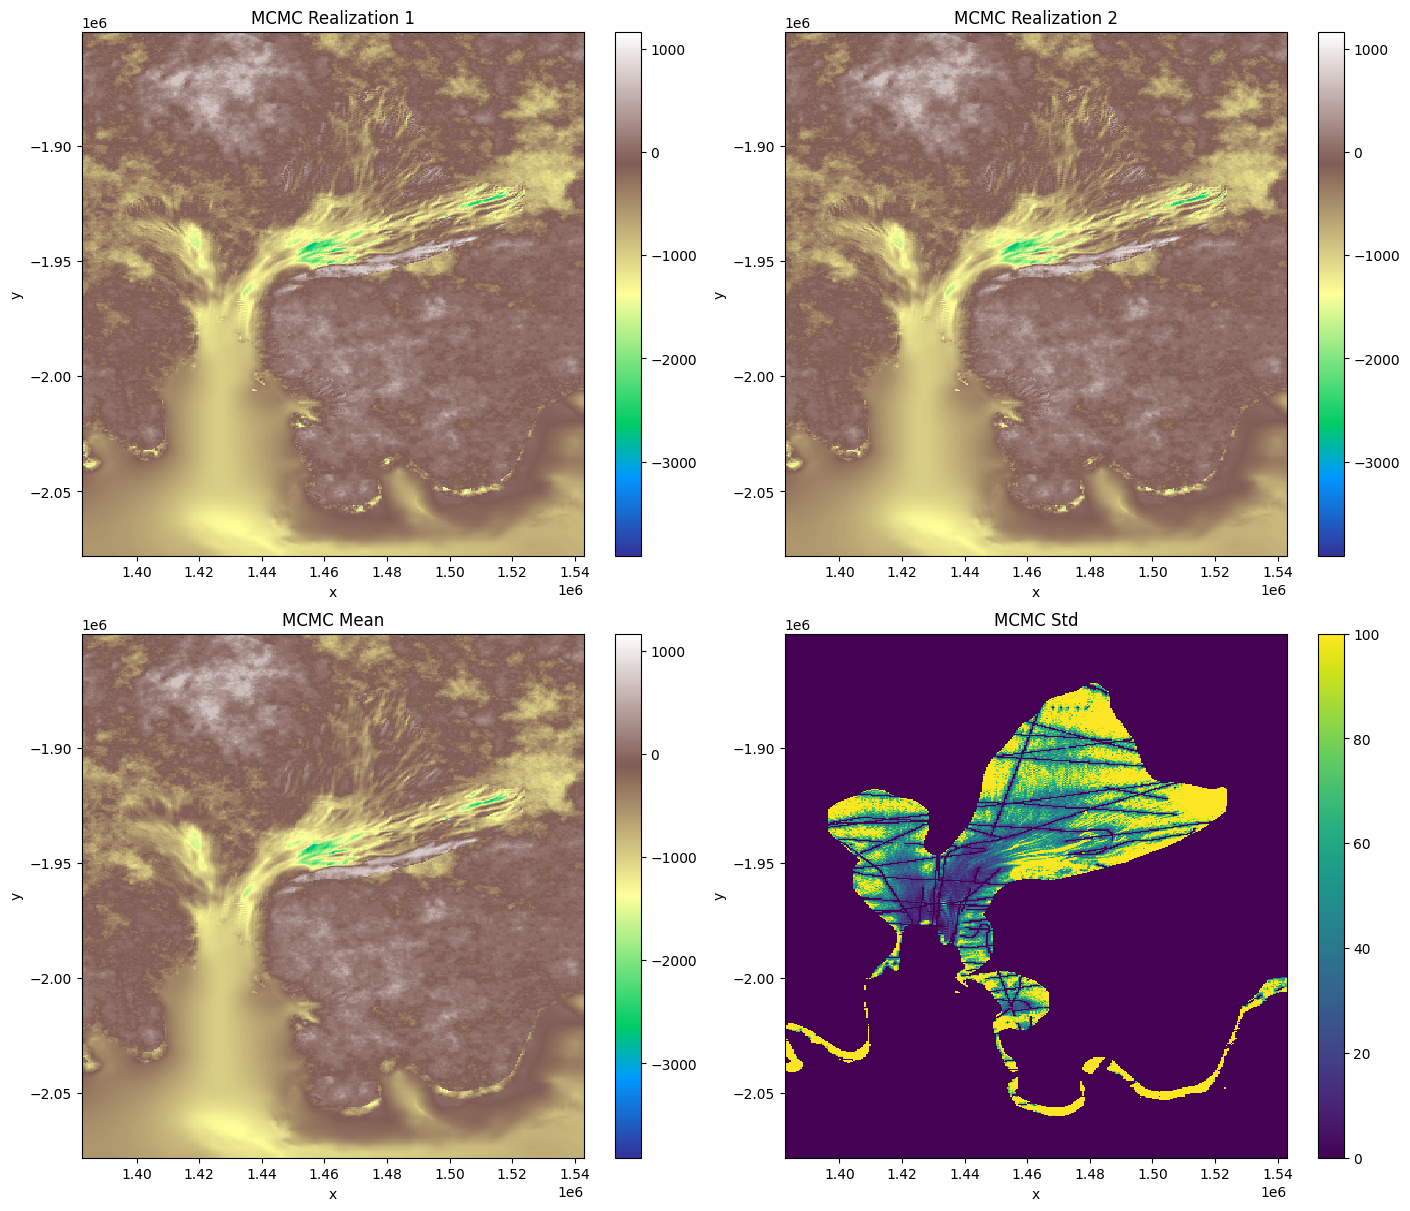

In [6]:
from pathlib import Path

mcmc_files = sorted(
    Path('MCMC_results').glob('MCMC_*.npy'),
    key=lambda path: int(path.stem.split('_')[1]),
)

if len(mcmc_files) != 100:
    raise ValueError(f'Expected 100 MCMC files, found {len(mcmc_files)}')

mcmc_stack = np.stack([np.load(path) for path in mcmc_files])

realization_1 = mcmc_stack[0]
realization_2 = mcmc_stack[1]
mcmc_mean = mcmc_stack.mean(axis=0)
mcmc_std = mcmc_stack.std(axis=0)

vmin = mcmc_stack.min()
vmax = mcmc_stack.max()

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

plots = [
    (realization_1, 'MCMC Realization 1', 'terrain', vmin, vmax),
    (realization_2, 'MCMC Realization 2', 'terrain', vmin, vmax),
    (mcmc_mean, 'MCMC Mean', 'terrain', vmin, vmax),
    (mcmc_std, 'MCMC Std', 'viridis', None, 100),
]

for ax, (grid, title, cmap, plot_vmin, plot_vmax) in zip(axes.flat, plots):
    im = ax.pcolormesh(xx, yy, grid, cmap=cmap, vmin=plot_vmin, vmax=plot_vmax)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax)

plt.show()

In [7]:
mask = df['highvel_mask'].values.reshape(xx.shape)
df['bed_cond'] = df.bedmap_surf - df.radar_thickness
radar_bed = df['bed_cond'].values.reshape(xx.shape)
bedmachine_bed = df['bedmachine_bed'].values.reshape(xx.shape)
bedmap_mask = df['bedmap_mask'].values.reshape(xx.shape)

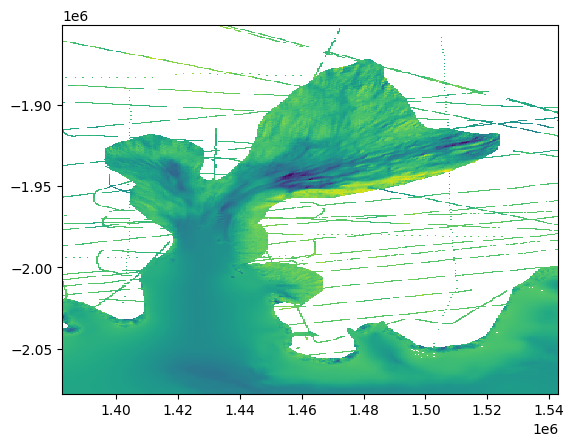

In [8]:
# mask out bed
#bed_masked = np.where(mask == 1, beds, radar_bed)

bed_masked = np.where(
    (mask == 1) | (bedmap_mask == 3) | np.isnan(bedmap_mask),
    beds,
    radar_bed
)
plt.pcolormesh(xx,yy,bed_masked)

In [26]:
# mask of inversion domain
inv_masked = np.where(mask == 1, beds, np.nan)

In [27]:
area = np.isfinite(inv_masked)

# 2. Get x/y coordinates of those cells
x_points = xx[area]
y_points = yy[area]

# 3. Make a 5 km buffer mask
buffer_mask = vd.distance_mask(
    data_coordinates=(x_points, y_points),
    maxdist=5000,                 # 5 km buffer
    coordinates=(xx, yy)
)

# 4. Convert to integer mask if you want 1 inside buffer, 0 outside
buffer_mask = buffer_mask.astype(int)
buffer_mask_before_exclude = buffer_mask.copy()

In [28]:
edge_buffer = np.zeros_like(buffer_mask, dtype=bool)

n = 10  # 5 km / 500 m = 10 cells

edge_buffer[:n, :] = True       # bottom
edge_buffer[-n:, :] = True      # top
edge_buffer[:, :n] = True       # left
edge_buffer[:, -n:] = True      # right

In [29]:
exclude = (
    (~np.isnan(inv_masked)) |
    (mask == 1) |
    (bedmap_mask == 3) |
    np.isnan(bedmap_mask) |
    edge_buffer
)

buffer_mask[exclude] = 0

In [30]:
# plotted below in the combined 2x2 figure

In [31]:
beds_updated = np.where(buffer_mask == 1, radar_bed, beds)

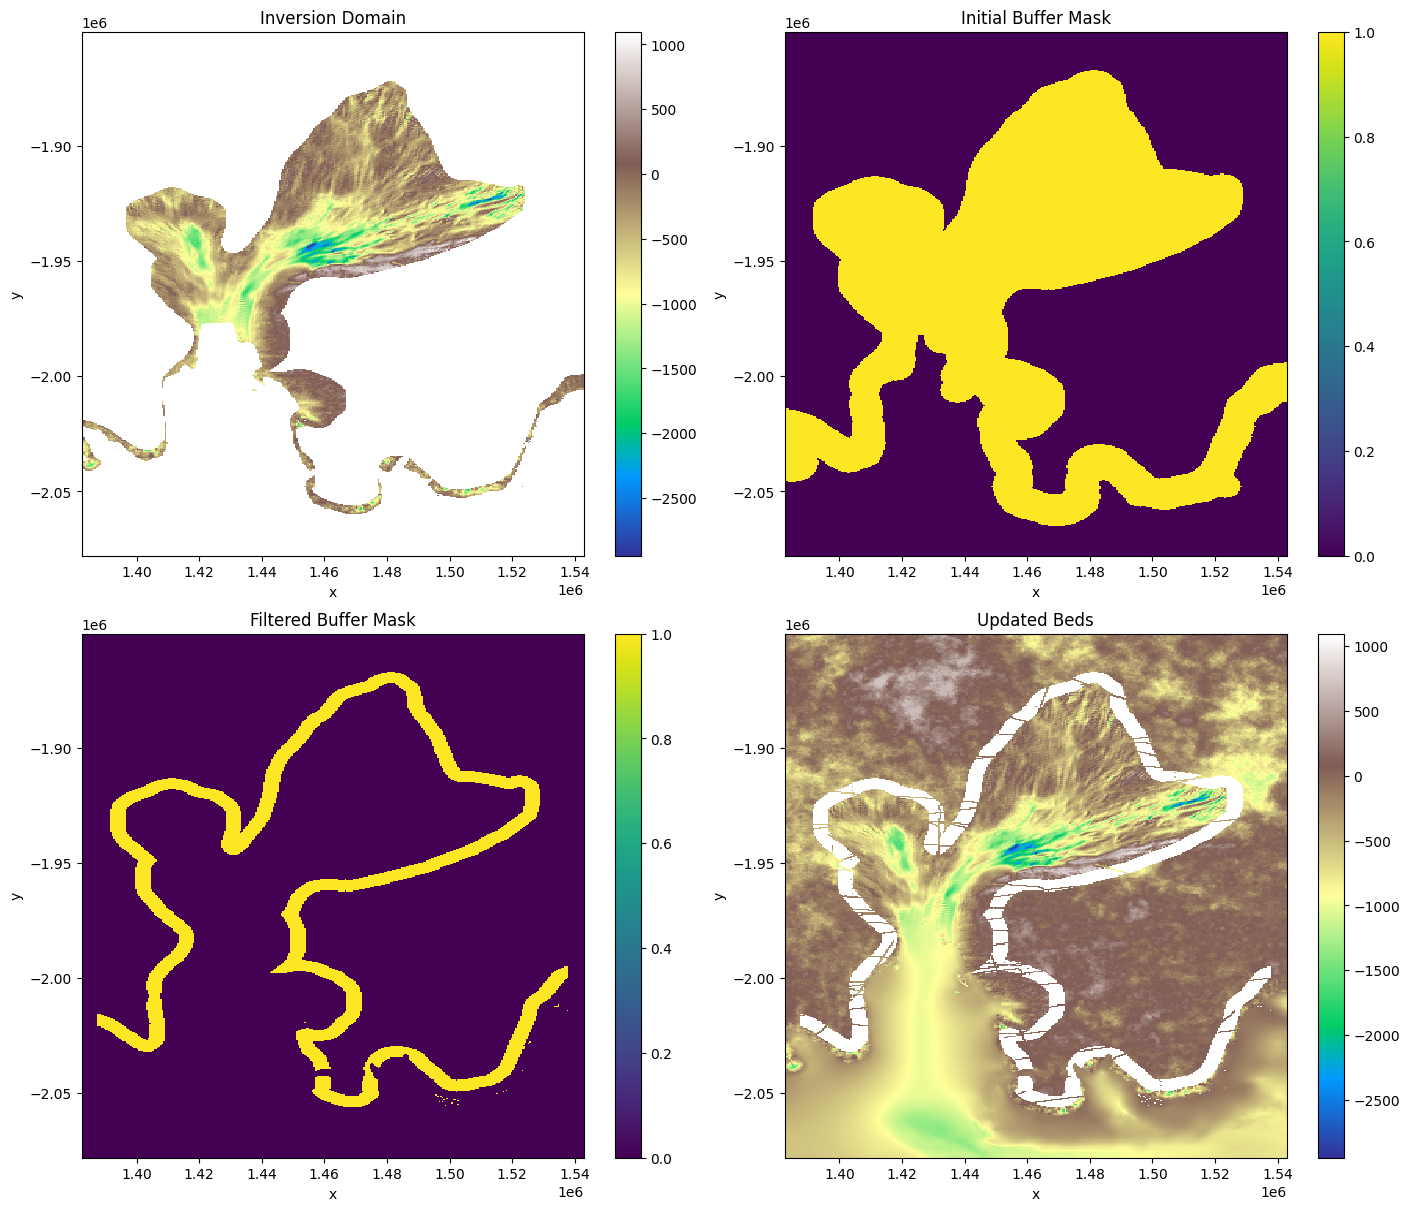

In [32]:
bed_vmin = np.nanmin(np.stack([inv_masked, beds_updated]))
bed_vmax = np.nanmax(np.stack([inv_masked, beds_updated]))

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

plots = [
    (inv_masked, 'Inversion Domain', 'terrain', bed_vmin, bed_vmax),
    (buffer_mask_before_exclude, 'Initial Buffer Mask', 'viridis', 0, 1),
    (buffer_mask, 'Filtered Buffer Mask', 'viridis', 0, 1),
    (beds_updated, 'Updated Beds', 'terrain', bed_vmin, bed_vmax),
]

for ax, (grid, title, cmap, plot_vmin, plot_vmax) in zip(axes.flat, plots):
    im = ax.pcolormesh(xx, yy, grid, cmap=cmap, vmin=plot_vmin, vmax=plot_vmax)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax)

plt.show()

## SGS the results

In [ ]:
import gstatsim as gs
import skgstat as skg
from skgstat import models
import random

k = 50      # number of neighboring data points used to estimate a given point 
rad = 30000    # search radius
rng = np.random.default_rng(seed=2002)


azimuth=0
nugget=0
major_range=140743
minor_range= 140743
sill =0.85
vtype=  'matern'
s = 0.66

param = [np.float64(140743),
 np.float64(0.85),
 np.float64(0.66),
 0]

vtype = 'Matern'
azimuth = 0
# vario4 = [azimuth, param[-1], param[0], param[0], param[1], vtype, param[2]]
vario4 = [azimuth, nugget, major_range, minor_range, sill, vtype, s]

# define coordinate grid
xmin = xx.min(); xmax = xx.max()     # min and max x values
ymin = yy.min(); ymax = yy.max()     # min and max y values
res = 1000

Pred_grid_xy = gs.Gridding.prediction_grid(xmin, xmax, ymin, ymax, res)


100%|██████████| 36708/36708 [00:40<00:00, 897.86it/s] 


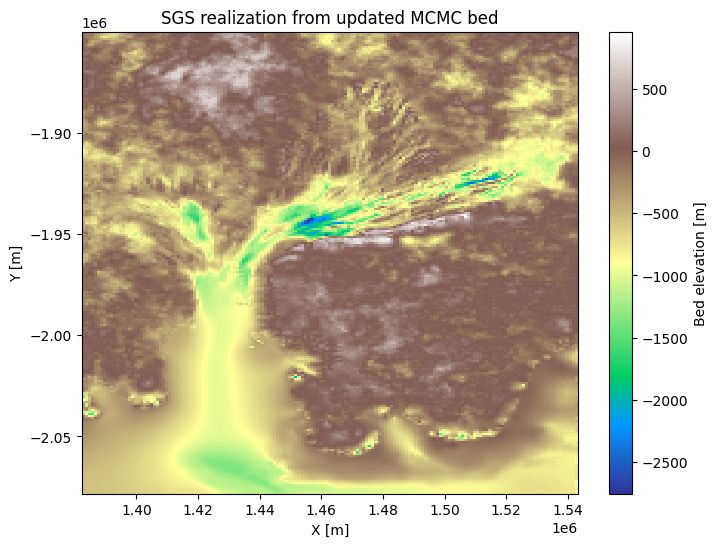

In [ ]:
from sklearn.preprocessing import QuantileTransformer

# build conditioning data from the updated MCMC bed surface and grid it to the SGS resolution
df_bed = pd.DataFrame({
    'X': xx.ravel(),
    'Y': yy.ravel(),
    'Bed': beds_updated.ravel(),
})

df_grid, grid_matrix, rows_sgs, cols_sgs = gs.Gridding.grid_data(df_bed, 'X', 'Y', 'Bed', res)
df_grid = df_grid[df_grid['Z'].notnull()].copy()

# learn the normal-score transform from the valid gridded bed elevations
bed_data = df_grid['Z'].values.reshape(-1, 1)
n_quantiles = min(500, len(df_grid))
nst_trans = QuantileTransformer(
    n_quantiles=n_quantiles,
    output_distribution='normal',
    random_state=0,
).fit(bed_data)
df_grid['Nbed'] = nst_trans.transform(bed_data)

# run SGS in transformed space, then inverse-transform back to bed elevation
sim_matern = gs.Interpolation.okrige_sgs(
    Pred_grid_xy,
    df_grid,
    'X',
    'Y',
    'Nbed',
    k,
    vario4,
    rad,
    seed=rng,
)
sim_matern = sim_matern.reshape(-1, 1)
sim_matern_trans = nst_trans.inverse_transform(sim_matern)

rows_pred = len(np.unique(Pred_grid_xy[:, 1]))
cols_pred = len(np.unique(Pred_grid_xy[:, 0]))
x_mat = Pred_grid_xy[:, 0].reshape((rows_pred, cols_pred))
y_mat = Pred_grid_xy[:, 1].reshape((rows_pred, cols_pred))
sim_matern_mat = sim_matern_trans.reshape((rows_pred, cols_pred))



In [1]:
from scipy.interpolate import RegularGridInterpolator

bed_interp = RegularGridInterpolator(
    (y_uniq, x_uniq),
    beds,
    bounds_error=False,
    fill_value=np.nan,
)

bed_porj = bed_interp(Pred_grid_xy[:, [1, 0]]).reshape(rows_pred, cols_pred)
plt.figure(figsize=(8, 6))
im = plt.pcolormesh(x_mat, y_mat, sim_matern_mat-bed_porj, cmap='terrain')
plt.contour(xx, yy, buffer_mask.astype(float), levels=[0.5], colors='red', linewidths=1.2)
plt.colorbar(im, label='Bed elevation [m]')
plt.title('SGS realization from updated MCMC bed')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.show()

NameError: name 'y_uniq' is not defined